# Environment

In [1]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../01_Functions_classes_and_variables").resolve()
sys.path.append(str(module_path))

from simulation_data_functions import *
from data_exploration_functions import *
from data_operations_functions import *
from modelling_functions import *
from libraries_and_variables import *

from joblib import Parallel, delayed

#from sklearn.metrics import r2_score

In [2]:
repo_path_wndws = Path("../").resolve()
repo_path_unix = repo_path_wndws.as_posix() 
repo_path_r_string = repo_path_unix.replace("/", '\\')

# Data

## Loading

In [3]:
dict_of_combs = generate_dict_of_combs(base_pairs, third_values)
connection_link_var = repo_path_r_string + r'\03_simulated_data\simulated_data_effect_size.sqlite'
dict_of_gdfs = {}
for i in dict_of_combs:

        df = import_non_spatial_data_frame(
                connection_link = connection_link_var,
                df_to_return_name =  i
        )
        gdf = gpd.GeoDataFrame(
                df,
                geometry=gpd.points_from_xy(df["x"], df["y"]),
                crs="EPSG:3857"
                )
        
        dict_of_gdfs[i] = gdf

## Checking

In [4]:
len(dict_of_gdfs.keys())

1000

<Axes: >

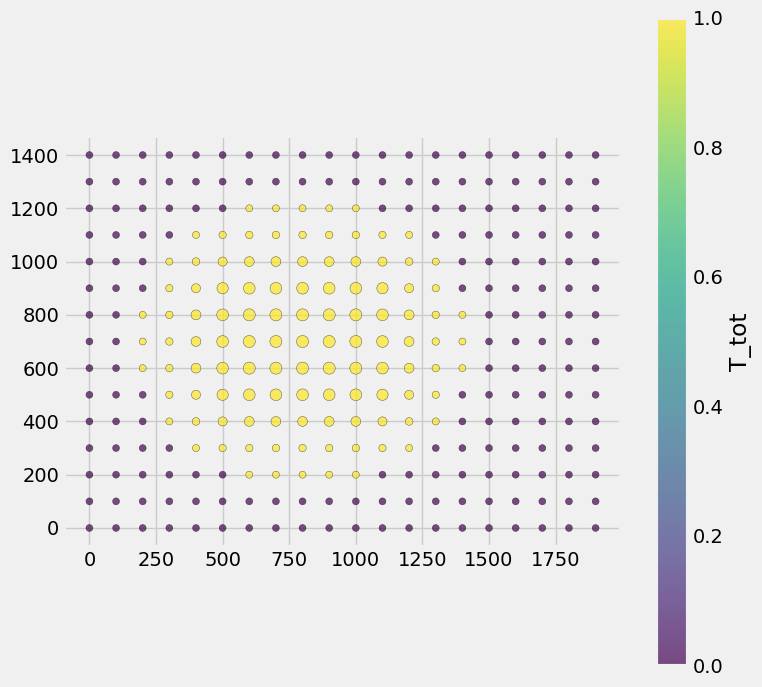

In [7]:
temp_gdf = dict_of_gdfs[list(dict_of_gdfs.keys())[0]].copy()
temp_gdf['spill2'] = temp_gdf['spill'] + 0.5
plot_gdf_points(temp_gdf, size_col='spill2',
    color_col='T_tot')

# Modelling causal inference

In [8]:
replacing_dict_0_ring = {0:'treated_inner_ring', 1:'treated_outer_ring1', 
                                             2:'treated_outer_ring2',
                                             3:'treated_outer_ring3',
                                             4:'treated_outer_ring4'
                                             }

replacing_dict_odr_ring = {'T':'treated_inner_ring', 
                                                                        'ODR_1':'treated_outer_ring1', 
                                                                        'ODR_2':'treated_outer_ring2',
                                                                        'ODR_3':'treated_outer_ring3',
                                                                        'ODR_4':'treated_outer_ring4'
                                                                          }

In [9]:
list_of_output_dfs = Parallel(
    n_jobs=-1,
    backend="loky",
    verbose=10
)(
    delayed(process_single_key)(i, replacing_dict_0_ring, replacing_dict_odr_ring, dict_of_gdfs, dict_of_combs)
    for i in dict_of_gdfs.keys()
)

df_results = pd.concat(list_of_output_dfs, ignore_index=True)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   44.1s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:  4.2min
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:  4.8min
[Parallel(n_jobs=-1)]: Done  61 tasks      | elapsed:  6.0min
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:  7.2min
[Parallel(n_jobs=-1)]: Done  89 tasks      | elapsed:  8.1min
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:  9.4min
[Parallel(n_jobs=-1)]: Done 121 tasks      | elapsed: 10.7min
[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed: 12.0min
[Parallel(n_jobs=-1)]: Done 157 tasks      | elapsed: 13.4min
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed: 14.9min
[Parallel(n_jobs=-1)]: Done 197 tasks      | elapsed: 1

# Data saving

In [10]:
df_results.to_csv(repo_path_r_string + r'\05_results\01_data\modelling_results.csv')